In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [70]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_merged.csv')

In [71]:
df.head()

,Date,Time,Item,Qty,Net_Sales,Size,Milk,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-11,14:44:57,Matcha Latte,1.0,9.0,16oz,Whole Milk,1.0,Blueberry,84.0,Sunny,Popup,Islands Boutique
1,2026-06-11,14:43:02,Matcha Latte,1.0,7.0,12oz,NaN,0.0,Strawberry,84.0,Sunny,Popup,Islands Boutique
2,2026-06-11,14:39:31,Lemonade,2.0,10.0,16oz,NaN,0.0,Strawberry,84.0,Sunny,Popup,Islands Boutique
3,2026-06-11,14:31:49,Matcha Latte,1.0,9.0,16oz,Whole Milk,1.0,Blueberry,84.0,Sunny,Popup,Islands Boutique
4,2026-06-11,14:24:41,Matcha Latte,1.0,9.0,16oz,Oat Milk,1.0,Strawberry,84.0,Sunny,Popup,Islands Boutique


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               433 non-null    object 
 1   Time               433 non-null    object 
 2   Item               433 non-null    object 
 3   Qty                433 non-null    float64
 4   Net_Sales          433 non-null    float64
 5   Size               359 non-null    object 
 6   Milk               164 non-null    object 
 7   Cold_Foam          330 non-null    float64
 8   Flavor             312 non-null    object 
 9   Avg_Temp           428 non-null    float64
 10  Weather_Condition  428 non-null    object 
 11  Event_Type         428 non-null    object 
 12  Location           428 non-null    object 
dtypes: float64(4), object(9)
memory usage: 44.1+ KB


In [73]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte      2029.24
Cold Brew          694.00
Lemonade           323.00
Ashlen             109.00
Sticker             76.00
Lemon Dream         28.18
Aaron               22.00
Maple Pancakes      16.00
Custom Amount        1.00
Name: Net_Sales, dtype: float64

In [74]:
df.groupby("Flavor")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Flavor
Strawberry                 981.58
Blueberry                  525.00
Salted Maple               381.66
Cinn Roll                  224.00
Cake Batter                216.00
Vanilla                    114.00
Lemonade, Strawberry        64.00
Lemonade                    22.00
Blueberry, Lemonade          8.00
Cake Batter, Sprinkles!      8.00
Name: Net_Sales, dtype: float64

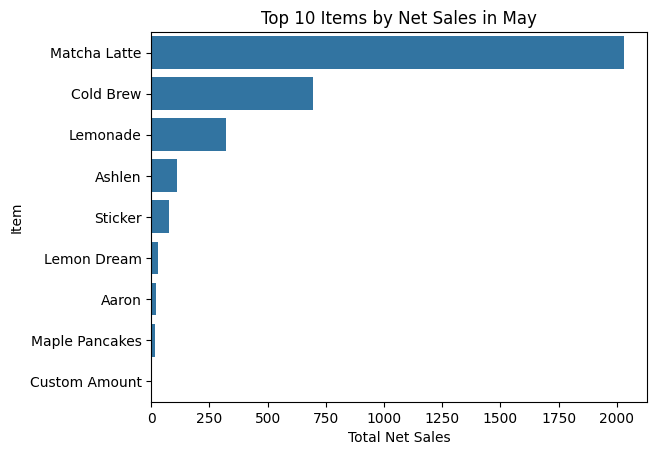

In [75]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()

In [76]:
df.groupby("Item")["Qty"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte      252.0
Cold Brew          97.0
Lemonade           71.0
Sticker            38.0
Ashlen             14.0
Aaron               5.0
Lemon Dream         4.0
Maple Pancakes      2.0
Custom Amount       1.0
Name: Qty, dtype: float64

In [77]:
df.groupby("Event_Type")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Event_Type
Market    2342.42
Popup      898.00
Name: Net_Sales, dtype: float64

In [78]:
df["Cold_Foam"].value_counts()

Cold_Foam
1.0    194
0.0    136
Name: count, dtype: int64

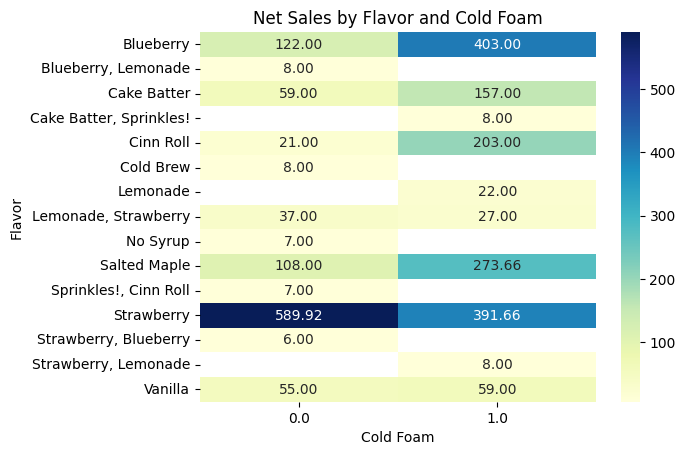

In [80]:
pivot = df.pivot_table(
    index="Flavor",
    columns="Cold_Foam",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Cold Foam")
plt.xlabel("Cold Foam")
plt.ylabel("Flavor")
plt.show()

In [81]:
df["Flavor"].value_counts()

Flavor
Strawberry                 121
Blueberry                   64
Salted Maple                47
Cinn Roll                   27
Cake Batter                 22
Vanilla                     13
Lemonade, Strawberry         8
Lemonade                     3
No Syrup                     1
Sprinkles!, Cinn Roll        1
Cold Brew                    1
Strawberry, Blueberry        1
Cake Batter, Sprinkles!      1
Strawberry, Lemonade         1
Blueberry, Lemonade          1
Name: count, dtype: int64

In [82]:
df['Item'].unique()

array(['Matcha Latte', 'Lemonade', 'Aaron', 'Sticker', 'Cold Brew',
       'Ashlen', 'Lemon Dream', 'Maple Pancakes', 'Custom Amount'],
      dtype=object)